# Single-session transformer exploration

Load one cropped session, run the masked transformer, and explore **reconstruction**, **latents**, and **attention**.

In [7]:
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.decomposition import PCA

from behavex.models.extract_latents import _load_model_from_checkpoint, load_single_session_windows
from behavex.models.inspect_transformer import forward_with_attention
from behavex.models.transformer import reconstruction_loss, predictive_loss

# Config
SESSION_PATH = "/Users/thomasbush/Downloads/shared WithTWB/m001_s001_cricket.xlsx"
START_TIMES_PATH = "/Users/thomasbush/Downloads/shared WithTWB/startTimes.xlsx"
CHECKPOINT_PATH = "/Users/thomasbush/Downloads/models/masked_transformer_20260206_132007/best.pt"  # adjust to your run
WINDOW_SIZE = 128
DEVICE = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"

In [2]:
# Load single session (cropped before start time) and build windows
windows, feature_names = load_single_session_windows(
    SESSION_PATH, start_times_path=START_TIMES_PATH, window_size=WINDOW_SIZE
)
print(f"Windows: {windows.shape}, features: {len(feature_names) or windows.shape[-1]}")

Windows: (19337, 128, 24), features: 24


In [3]:
# Load model from checkpoint
model = _load_model_from_checkpoint(Path(CHECKPOINT_PATH), torch.device(DEVICE))
model.eval()

MaskedPredictiveTemporalTransformer(
  (embedding): Linear(in_features=24, out_features=32, bias=True)
  (pos_encoder): RotaryPositionalEmbeddings()
  (norm): RMSNorm()
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-11): 12 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=64, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=64, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (reconstruction_head): Linear(in_features=32, out_features=24, bias=True)
  (prediction_head): Linear(in_features=32, out_features

In [4]:
# Run inference (no mask) and compute performance
batch_size = 64
recon_losses, pred_losses = [], []
all_latents, all_recon = [], []
is_predictive = hasattr(model, "n_predict_steps") and model.n_predict_steps is not None

with torch.no_grad():
    for i in range(0, len(windows), batch_size):
        X = torch.from_numpy(windows[i : i + batch_size]).float().to(DEVICE)
        B, T, _ = X.shape
        mask = torch.zeros(B, T, dtype=torch.bool, device=DEVICE)
        out = model(X, mask=mask)
        recon, latent = out[0], out[1]
        loss = torch.nn.functional.mse_loss(recon, X).item()
        recon_losses.append(loss)
        all_latents.append(latent.cpu().numpy())
        all_recon.append(recon.cpu().numpy())
        if is_predictive:
            pred_losses.append(predictive_loss(out[3], X, model.n_predict_steps).item())

recon_mse = np.mean(recon_losses)
print(f"Reconstruction MSE (session): {recon_mse:.6f}")
if is_predictive and pred_losses:
    print(f"Prediction loss (session): {np.mean(pred_losses):.6f}")

latents = np.concatenate(all_latents, axis=0)
recons = np.concatenate(all_recon, axis=0)

Reconstruction MSE (session): 0.183340
Prediction loss (session): 0.227169


In [5]:
# Run one batch with attention for visualization
X_batch = torch.from_numpy(windows[:batch_size]).float().to(DEVICE)
with torch.no_grad():
    recon_attn, latent_attn, _, attention_per_layer = forward_with_attention(
        model, X_batch, mask=None, average_attn_weights=True
    )
print(f"Attention: {len(attention_per_layer)} layers, shape per layer: {attention_per_layer[0].shape}")

Attention: 12 layers, shape per layer: torch.Size([64, 128, 128])


## Plots

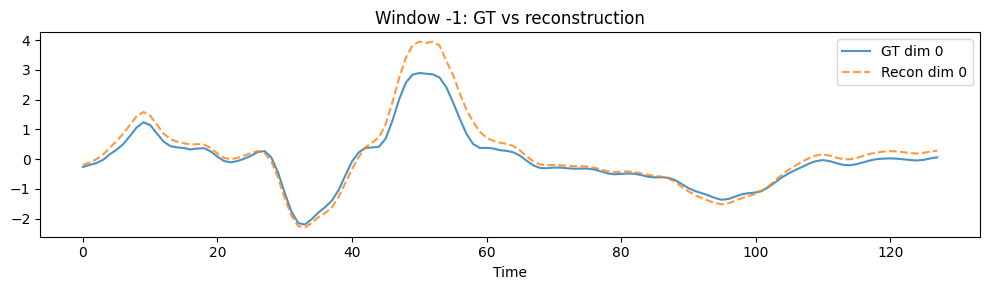

In [52]:
# Recon vs GT for one window (first 2 feature dims)
win_idx = -1
fig, ax = plt.subplots(1, 1, figsize=(10, 3))
t = np.arange(windows.shape[1])
ax.plot(t, windows[win_idx, :, 10], label="GT dim 0", alpha=0.8)
ax.plot(t, recons[win_idx, :, 10], label="Recon dim 0", linestyle="--", alpha=0.8)
ax.set_xlabel("Time")
ax.legend()
ax.set_title(f"Window {win_idx}: GT vs reconstruction")
plt.tight_layout()
plt.show()

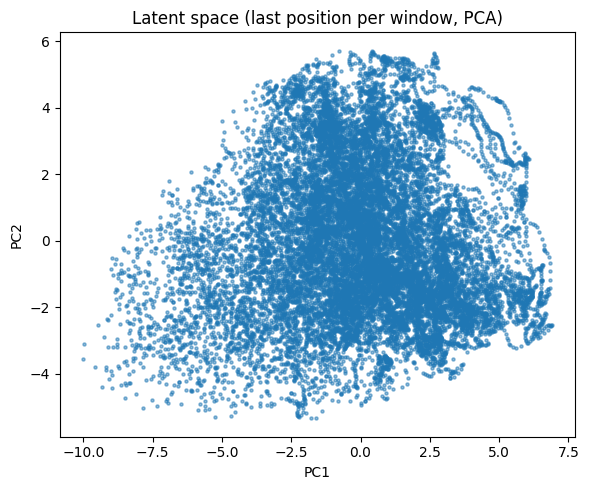

In [55]:
# Latent PCA: use last timestep of each window
latent_last = latents[:, -1, :]  # (N_windows, d_model)
pca = PCA(n_components=2)
latent_2d = pca.fit_transform(latent_last)
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax.scatter(latent_2d[:, 0], latent_2d[:, 1], alpha=0.5, s=5)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Latent space (last position per window, PCA)")
plt.tight_layout()
plt.show()

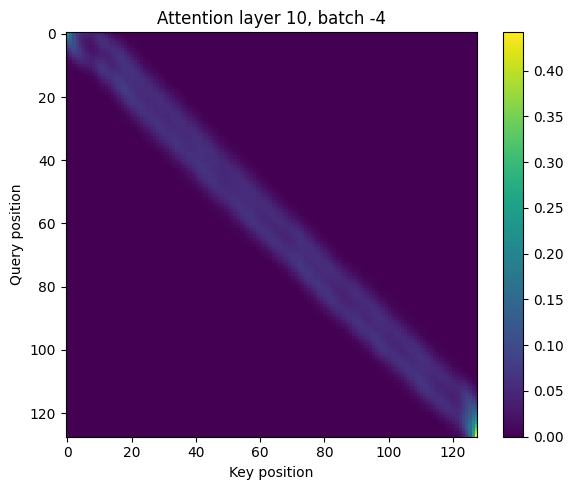

In [56]:
# Attention heatmap: layer 0, batch index 0
layer_idx = 10
batch_idx = -4
attn = attention_per_layer[layer_idx][batch_idx].cpu().numpy()  # (T, T)
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
im = ax.imshow(attn, aspect="auto", cmap="viridis")
ax.set_xlabel("Key position")
ax.set_ylabel("Query position")
ax.set_title(f"Attention layer {layer_idx}, batch {batch_idx}")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()